In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# Any results you write to the current directory are saved as output.

['train.csv', 'gender_submission.csv', 'test.csv']
/kaggle/input/train.csv
/kaggle/input/gender_submission.csv
/kaggle/input/test.csv


In [2]:
import matplotlib.pyplot 
import seaborn as sns

In [3]:
dataset = pd.read_csv('../input/train.csv')
train = pd.read_csv('../input/train.csv')
test = pd.read_csv('../input/test.csv')

In [4]:
Y_train = train.iloc[:,1].values
train.drop(columns=['Survived','Name','Ticket'],axis=1,inplace=True)
train.drop(columns=['Embarked','Cabin'],axis=1,inplace=True)
train = pd.get_dummies(train,columns=['Sex'],drop_first=True)

In [5]:
train.drop(columns=['PassengerId'],axis=1,inplace=True)

In [6]:
mean_value=train['Age'].mean()
train['Age']=train['Age'].fillna(mean_value)

mean_val=train['Fare'].mean()
train['Fare']=train['Fare'].fillna(mean_val)

In [7]:
X_train = train.iloc[:,:].values

**Exploratory Data Analysis**

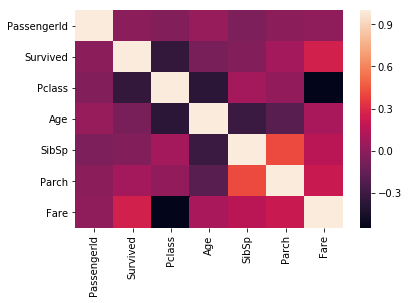

In [8]:
sns.heatmap(dataset.corr())

In [9]:
dataset.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


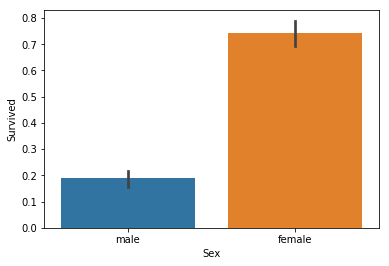

In [10]:
sns.barplot(x='Sex',y='Survived',data=dataset)

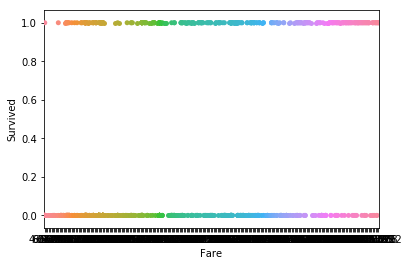

In [11]:
sns.stripplot(x='Fare',y='Survived',data=dataset)

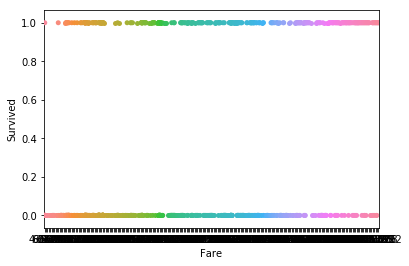

In [12]:
sns.swarmplot(x='Fare',y='Survived',data=dataset)

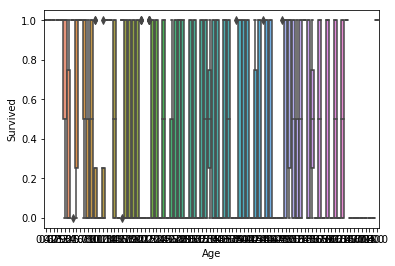

In [13]:
sns.boxplot(x='Age',y='Survived',data=dataset)

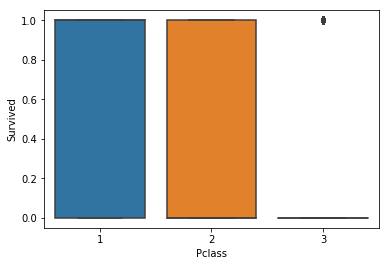

In [14]:
sns.boxplot(x='Pclass',y='Survived',data=dataset)

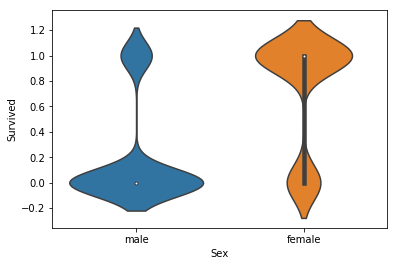

In [15]:
sns.violinplot(x='Sex',y='Survived',data=dataset)

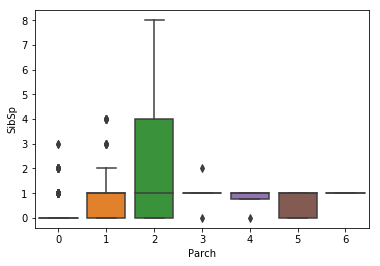

In [16]:
sns.boxplot(x='Parch',y='SibSp',data=dataset)

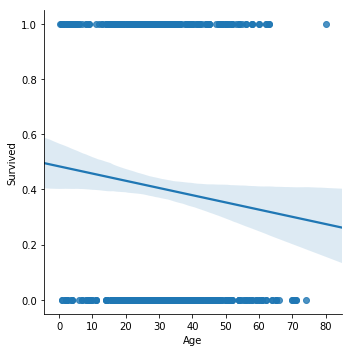

In [17]:
sns.lmplot(x='Age',y='Survived',data=dataset)

**Analysis**

In [18]:
test.drop(columns=['Name','Ticket'],axis=1,inplace=True)
test.drop(columns=['Embarked','Cabin'],axis=1,inplace=True)
test.drop(columns=['PassengerId'],axis=1,inplace=True)
test = pd.get_dummies(test,columns=['Sex'],drop_first=True)

In [19]:
mean_value=test['Age'].mean()
test['Age']=test['Age'].fillna(mean_value)

mean_val=test['Fare'].mean()
test['Fare']=test['Fare'].fillna(mean_val)

In [20]:
X_test = test.iloc[:,:].values

*Decision Tree*

In [21]:
from sklearn.tree import DecisionTreeClassifier
dectree = DecisionTreeClassifier()
dectree.fit(X_train, Y_train)
y_pred = dectree.predict(X_test)

In [22]:
gender = pd.read_csv('../input/gender_submission.csv')
y_test = gender.iloc[:,1].values

In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85       266
           1       0.75      0.73      0.74       152

    accuracy                           0.81       418
   macro avg       0.80      0.80      0.80       418
weighted avg       0.81      0.81      0.81       418



*Random Forest*

In [24]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier()
random_forest.fit(X_train, Y_train)
y_pred = random_forest.predict(X_test)

/opt/conda/lib/python3.6/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       266
           1       0.77      0.71      0.74       152

    accuracy                           0.82       418
   macro avg       0.81      0.80      0.80       418
weighted avg       0.82      0.82      0.82       418



*XGBoost*

In [26]:
import xgboost as xgb
model=xgb.XGBClassifier(random_state=1,learning_rate=0.01)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
model.score(X_test,y_test)

0.9641148325358851

In [27]:
df_test = pd.read_csv('../input/test.csv')

In [28]:
submission = pd.DataFrame({'PassengerId':df_test['PassengerId'],'Survived':y_pred})

In [29]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [30]:
filename = 'Titanic Predictions.csv'

submission.to_csv(filename,index=False)

print('Saved file: ' + filename)

Saved file: Titanic Predictions.csv
